In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [66]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
df.shape

(7043, 21)

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [69]:

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [70]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [90]:
 df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [72]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [73]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df["TotalCharges"] = imputer.fit_transform(df[["TotalCharges"]])

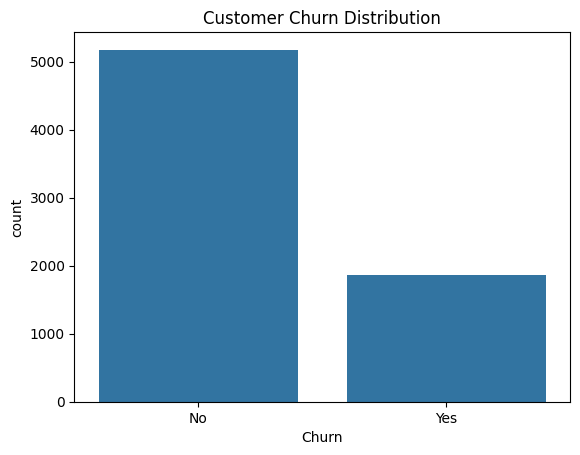

In [74]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [75]:
df.to_csv("../data/processed/cleaned_telco_churn.csv", index=False)

In [76]:
# supprimer ID
df = df.drop("customerID", axis=1)

# encoder target
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

# encoder variables catégorielles
df = pd.get_dummies(df, drop_first=True)

# séparer X et y
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [78]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [79]:

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [80]:
df.tail()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True
7042,0,66,105.65,6844.50,0,True,False,False,True,False,...,False,True,False,True,False,True,True,False,False,False


In [81]:
# Shape of dataset
print("Rows, Columns:", df.shape)

# Info about columns
print(df.info())

# Missing values
print(df.isnull().sum())

# Target distribution (assuming target column is 'Churn')
print(df['Churn'].value_counts())

Rows, Columns: (7043, 31)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bo

In [82]:
print("Rows, Columns:", df.shape)

Rows, Columns: (7043, 31)


In [83]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  InternetService

In [84]:
print(df.isnull().sum())

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

In [85]:
#Target distribution
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


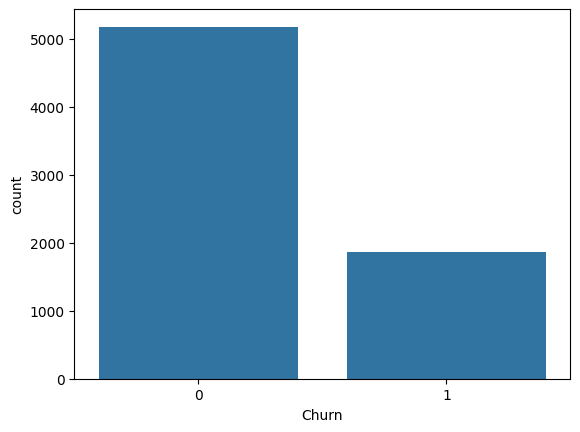

In [86]:
# Optional: plot it
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

In [87]:
# Numeric features
print(df.select_dtypes(include=['int64','float64']).describe())



       SeniorCitizen       tenure  MonthlyCharges  TotalCharges        Churn
count    7043.000000  7043.000000     7043.000000   7043.000000  7043.000000
mean        0.162147    32.371149       64.761692   2281.916928     0.265370
std         0.368612    24.559481       30.090047   2265.270398     0.441561
min         0.000000     0.000000       18.250000     18.800000     0.000000
25%         0.000000     9.000000       35.500000    402.225000     0.000000
50%         0.000000    29.000000       70.350000   1397.475000     0.000000
75%         0.000000    55.000000       89.850000   3786.600000     1.000000
max         1.000000    72.000000      118.750000   8684.800000     1.000000


In [ ]:
print(df.shape)

(7043, 31)


In [ ]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [ ]:
print(df.shape)

(7043, 21)


In [ ]:
df.head()

,"customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn"
0,"7590-VHVEG,Female,0,Yes,No,1,No,No phone servi..."
1,"5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Y..."
2,"3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,N..."
3,"7795-CFOCW,Male,0,No,No,45,No,No phone service..."
4,"9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic..."


In [ ]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
print(df.columns)

Index(['customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn'], dtype='str')


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
# Count of churn vs non-churn
print(df['Churn'].value_counts())


Churn
No     5174
Yes    1869
Name: count, dtype: int64


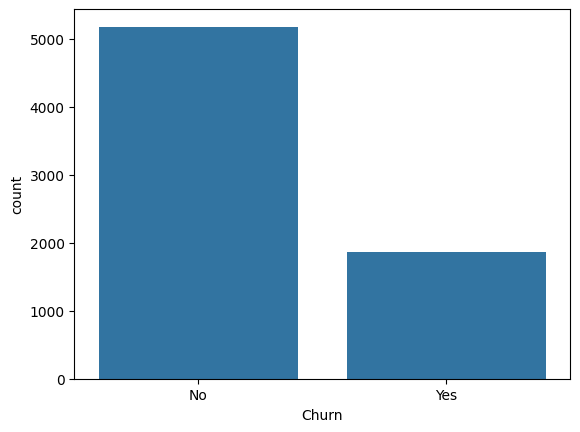

In [ ]:
# Plot distribution
sns.countplot(x='Churn', data=df)
plt.show()

In [ ]:
# Numeric features
print(df.select_dtypes(include=['int64', 'float64']).describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2281.916928
std         0.368612    24.559481       30.090047   2265.270398
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    402.225000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [ ]:
# Categorical features
print(df.select_dtypes(include=['object']).describe())

        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7043   7043    7043       7043         7043          7043   
unique        7043      2       2          2            2             3   
top     7590-VHVEG   Male      No         No          Yes            No   
freq             1   3555    3641       4933         6361          3390   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count             7043           7043         7043             7043   
unique               3              3            3                3   
top        Fiber optic             No           No               No   
freq              3096           3498         3088             3095   

       TechSupport StreamingTV StreamingMovies        Contract  \
count         7043        7043            7043            7043   
unique           3           3               3               3   
top             No          No              No  Month-to-month   
freq

C:\Users\sahar\AppData\Local\Temp\ipykernel_11392\1019548785.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).describe())


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataframe
df_model = df.copy()

# Encode binary categorical columns (Yes/No)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

# One-hot encode other categorical columns
df_model = pd.get_dummies(df_model, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8005677785663591

Confusion Matrix:
 [[953  82]
 [199 175]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.47      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



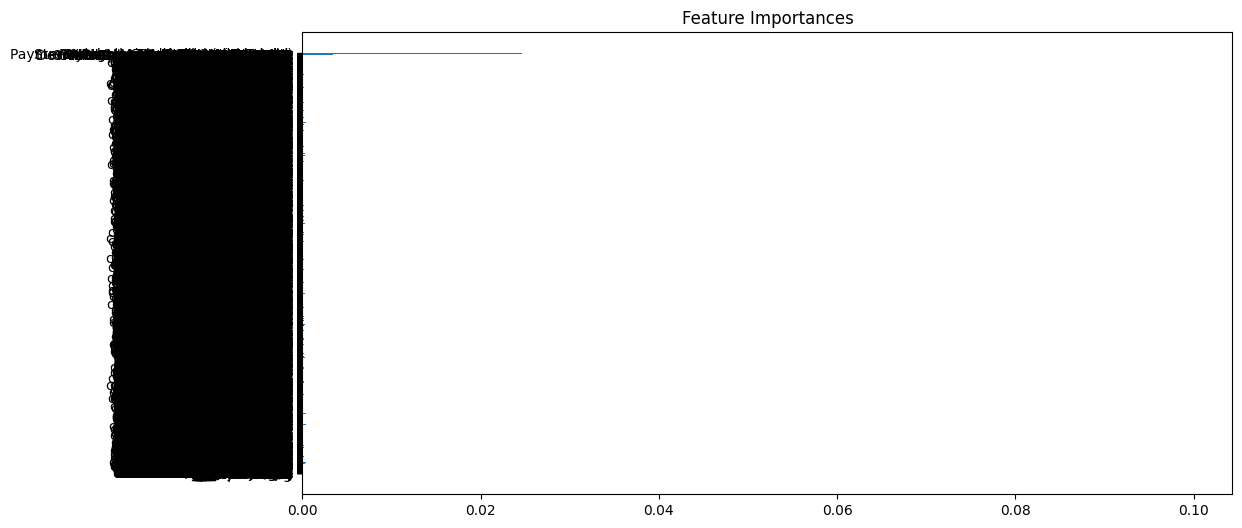

In [ ]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf.feature_importances_
features = X.columns
plt.figure(figsize=(12,6))
plt.barh(features, importances)
plt.title("Feature Importances")
plt.show()

In [ ]:
import joblib

# Save the model
joblib.dump(rf, "churn_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
joblib.dump(X.columns.tolist(), "features.pkl")
print("Features saved!")

Features saved!


In [ ]:
from flask import Flask, request, jsonify
import pandas as pd
import joblib

# Load model and features
model = joblib.load("churn_model.pkl")
features = joblib.load("features.pkl")

app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict():
    try:
        # Get JSON data from request
        data = request.get_json()
        
        # Convert to DataFrame
        df = pd.DataFrame([data])
        
        # One-hot encode missing columns
        for col in features:
            if col not in df.columns:
                df[col] = 0
        df = df[features]
        
        # Predict churn
        pred = model.predict(df)[0]
        pred_proba = model.predict_proba(df)[0][1]  # probability of churn
        
        return jsonify({
            "ChurnPrediction": int(pred),
            "ChurnProbability": float(pred_proba)
        })
    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == "__main__":
    app.run(debug=True)

ModuleNotFoundError: No module named 'flask'

In [ ]:
import joblib

# Save the trained model
joblib.dump(rf, "churn_model.pkl")

# Save the feature names (columns)
joblib.dump(X.columns.tolist(), "features.pkl")

print("Model and features saved successfully!")

Model and features saved successfully!


In [ ]:
from flask import Flask, request, jsonify
import pandas as pd
import joblib

# Load model and features
model = joblib.load("churn_model.pkl")
features = joblib.load("features.pkl")

app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict():
    try:
        # Get JSON data from request
        data = request.get_json()
        
        # Convert to DataFrame
        df = pd.DataFrame([data])
        
        # Ensure all features are present
        for col in features:
            if col not in df.columns:
                df[col] = 0
        df = df[features]
        
        # Make prediction
        pred = model.predict(df)[0]
        pred_proba = model.predict_proba(df)[0][1]  # probability of churn
        
        return jsonify({
            "ChurnPrediction": int(pred),
            "ChurnProbability": float(pred_proba)
        })
    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

c:\Users\sahar\Desktop\Customer_Churn_Project\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [92]:
from flask import Flask, request, jsonify
import pandas as pd
import joblib

# Load model and features
model = joblib.load("churn_model.pkl")
features = joblib.load("features.pkl")

app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        df = pd.DataFrame([data])
        for col in features:
            if col not in df.columns:
                df[col] = 0
        df = df[features]
        pred = model.predict(df)[0]
        pred_proba = model.predict_proba(df)[0][1]
        return jsonify({"ChurnPrediction": int(pred), "ChurnProbability": float(pred_proba)})
    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

c:\Users\sahar\Desktop\Customer_Churn_Project\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [97]:
import requests

url = "http://127.0.0.1:5000/predict"

data = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": 1,
    "Dependents": 0,
    "tenure": 12,
    "PhoneService": 1,
    "MultipleLines": 0,
    "InternetService": 1,
    "OnlineSecurity": 0,
    "OnlineBackup": 1,
    "DeviceProtection": 0,
    "TechSupport": 0,
    "StreamingTV": 1,
    "StreamingMovies": 0,
    "Contract": 1,
    "PaperlessBilling": 1,
    "PaymentMethod": 2,
    "MonthlyCharges": 70,
    "TotalCharges": 840
}

response = requests.post(url, json=data)
print(response.json())

{'ChurnPrediction': 0, 'ChurnProbability': 0.27}


In [ ]:
# ===============================================
# Step 0: Imports
# ===============================================
import requests
import pandas as pd






# ===============================================
# Step 1: Define the API URL
# ===============================================
url = "http://127.0.0.1:5000/predict"

# ===============================================
# Step 2: Example customer inputs
# Fill all 21 features exactly like your model expects
# ===============================================
customers = [
    {
        "gender": "Male",
        "SeniorCitizen": 0,
        "Partner": 1,
        "Dependents": 0,
        "tenure": 12,
        "PhoneService": 1,
        "MultipleLines": 0,
        "InternetService": 1,
        "OnlineSecurity": 0,
        "OnlineBackup": 1,
        "DeviceProtection": 0,
        "TechSupport": 0,
        "StreamingTV": 1,
        "StreamingMovies": 0,
        "Contract": 1,
        "PaperlessBilling": 1,
        "PaymentMethod": 2,
        "MonthlyCharges": 70,
        "TotalCharges": 840
    },
    {
        "gender": "Female",
        "SeniorCitizen": 1,
        "Partner": 0,
        "Dependents": 0,
        "tenure": 1,
        "PhoneService": 0,
        "MultipleLines": 0,
        "InternetService": 0,
        "OnlineSecurity": 0,
        "OnlineBackup": 0,
        "DeviceProtection": 0,
        "TechSupport": 0,
        "StreamingTV": 0,
        "StreamingMovies": 0,
        "Contract": 2,
        "PaperlessBilling": 1,
        "PaymentMethod": 0,
        "MonthlyCharges": 99,
        "TotalCharges": 99
    }
]

# ===============================================
# Step 3: Send requests and collect responses
# ===============================================
results = []
for cust in customers:
    response = requests.post(url, json=cust)
    results.append(response.json())

# ===============================================
# Step 4: Display results nicely
# ===============================================
df_results = pd.DataFrame(results)
df_results.index = ["Customer 1", "Customer 2"]
print(df_results)

            ChurnPrediction  ChurnProbability
Customer 1                0              0.27
Customer 2                1              0.69


In [101]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

# Load model and features
model = joblib.load("customer_Churn_Projrct/churn_model.pkl")
features = joblib.load("customer_Churn_Projrct/features.pkl")

app = FastAPI()

# Define request schema
class Customer(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: int
    Dependents: int
    tenure: int
    PhoneService: int
    MultipleLines: int
    InternetService: int
    OnlineSecurity: int
    OnlineBackup: int
    DeviceProtection: int
    TechSupport: int
    StreamingTV: int
    StreamingMovies: int
    Contract: int
    PaperlessBilling: int
    PaymentMethod: int
    MonthlyCharges: float
    TotalCharges: float

@app.post("/predict")
def predict(customer: Customer):
    df = pd.DataFrame([customer.dict()])
    for col in features:
        if col not in df.columns:
            df[col] = 0
    df = df[features]
    pred = model.predict(df)[0]
    pred_proba = model.predict_proba(df)[0][1]
    return {"ChurnPrediction": int(pred), "ChurnProbability": float(pred_proba)}

FileNotFoundError: [Errno 2] No such file or directory: 'customer_Churn_Projrct/churn_model.pkl'